In [1]:
import numpy as np
import matplotlib.pyplot as plt
from deepOnet_definitions import *
from FFEM_building_blocks import Mesh


In [2]:
# automatic generation of source functions and the Poisson solution algorithm

def generate_source_function(num_modes:int=4, max_freq:int=5, max_amplitude = 1.):
    """
    Uses a random truncated Fourier series with random amplitudes
    """
    # first pick some frequencies
    kx = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)
    ky = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)

    # now draw the corresponding amplitudes and phases
    amplitudes = np.random.uniform(-max_amplitude, max_amplitude, size=num_modes)
    phases = np.random.uniform(0, 2 * np.pi, size=num_modes)

    def source_function(x, y):
        result = 0
        for i in range(num_modes):
            result += amplitudes[i] * np.cos(kx[i] * x + ky[i] * y + phases[i])
        return result

    return source_function

In [3]:
x_branch = np.linspace(0, 2, 20)
y_branch = np.linspace(0, 2, 20)
X_branch, Y_branch = np.meshgrid(x_branch, y_branch, indexing="ij")
coords_branch = np.stack([X_branch.ravel(), Y_branch.ravel()], axis=-1)


don = deepOnet_v1(x_coords_for_branch = coords_branch, N_nodes_branch = 200, N_nodes_trunk = 200, latent_dimension = 200)

don.fit_from_npz('data/dataset.npz', 1000)

Epoch [100/1000], Loss: 0.0064
Epoch [200/1000], Loss: 0.0039
Epoch [300/1000], Loss: 0.0034
Epoch [400/1000], Loss: 0.0033
Epoch [500/1000], Loss: 0.0032
Epoch [600/1000], Loss: 0.0031
Epoch [700/1000], Loss: 0.0030
Epoch [800/1000], Loss: 0.0030
Epoch [900/1000], Loss: 0.0029
Epoch [1000/1000], Loss: 0.0029


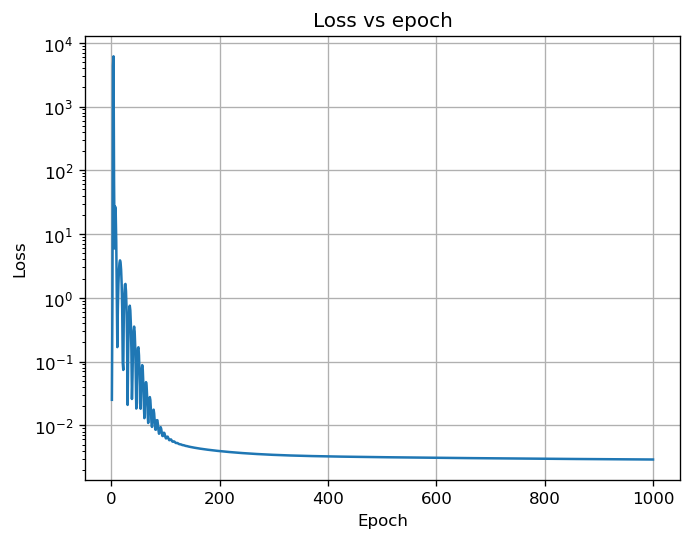

In [4]:
plt.figure(dpi = 120)
plt.title("Loss vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(don.epochs, don.losses)
plt.grid()
plt.show()

Mass matrix initialization completed
Stiffness matrix initialization completed


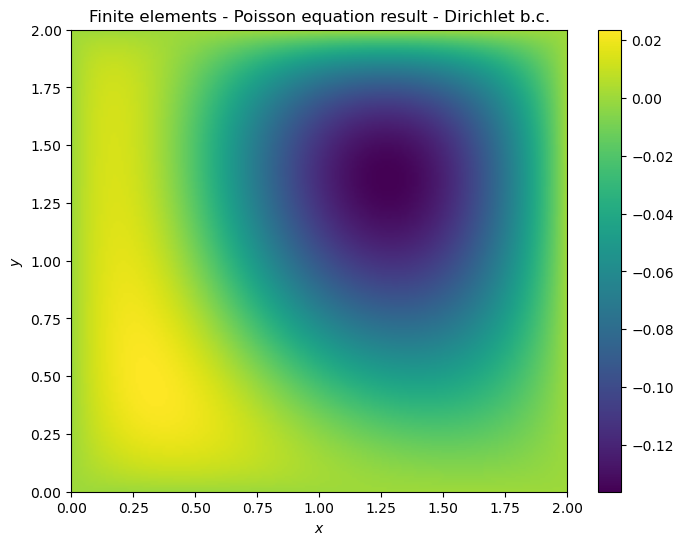

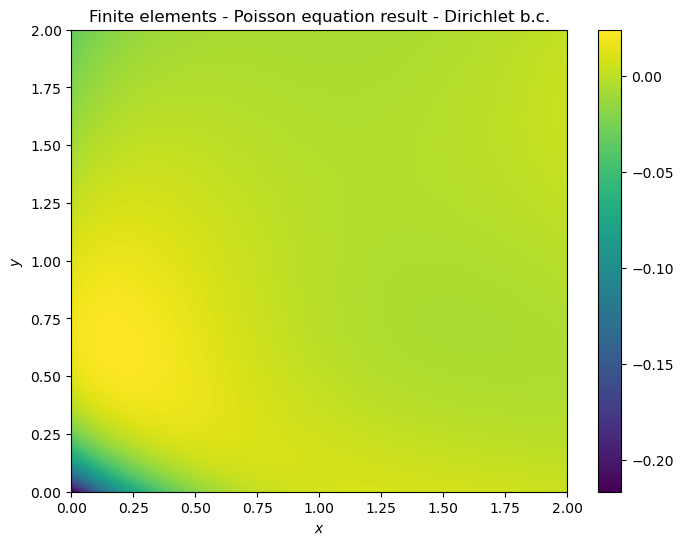

In [5]:
# now test visually on a randomly generated function

x = np.linspace(0, 2, 200)
y = np.linspace(0, 2, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()
# coordinates of mesh points 
X, Y = np.meshgrid(x, y, indexing="ij")
coords = np.stack([X.ravel(), Y.ravel()], axis=-1)
diri = lambda x, y: 0

func = generate_source_function()
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)
plt.figure(figsize=(8, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


result_don = don.map_function_to_output_at_points(func, np.array(coords)).squeeze(0).detach().numpy().reshape(200,200)
# detach to get rid of the tensor structure
# squeeze(0) to go from dimension (1, N) to (N)


plt.figure(figsize=(8, 6))
plt.imshow(result_don, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

In [6]:
# TO DO: more quantitative tests on a control dataset